## 1. Khai báo thư viện
Trong phần này, chúng ta sẽ import các thư viện cần thiết:
- `numpy`: Hỗ trợ thao tác với mảng đa chiều và sinh số ngẫu nhiên.
- `matplotlib.pyplot`: Sử dụng để trực quan hóa dữ liệu (vẽ biểu đồ hiệu năng). 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## 2. Các hàm Benchmark (Fitness Functions)
Cài đặt 3 hàm đánh giá độ thích nghi theo yêu cầu của bài toán:
1. **OneMax (100 bit):** Đếm số lượng bit `1` có trong chuỗi.
2. **LeadingOnes (20 bit):** Đếm số lượng bit `1` liên tiếp tính từ đầu chuỗi (từ trái sang phải).
3. **Concatenated Trap-5 (25 bit):** Chia chuỗi thành 5 khối, mỗi khối 5 bit. Độ thích nghi của mỗi khối bằng 5 nếu toàn bit `1`, ngược lại bằng `4 - số bit 1`.

In [46]:
def onemax(ind):
    return np.sum(ind)

def leadingones(ind):
    count = 0
    for bit in ind:
        if bit == 1:
            count += 1
        else:
            break
    return count

def trap5(ind):
    fitness = 0
    for i in range(0, len(ind), 5):
        block = ind[i:i+5]
        ones = np.sum(block)
        if ones == 5:
            fitness += 5
        else:
            fitness += (4 - ones)
    return fitness

## 3. Các cơ chế chọn lọc (Selection Mechanisms)
Cài đặt 3 phương pháp chọn lọc để giữ lại $N$ cá thể từ quần thể gộp $2N$ (bố mẹ + con cái):
- **Truncation Selection (Chọn lọc cắt cụt):** Sắp xếp quần thể theo fitness giảm dần và chọn ra $N$ cá thể xuất sắc nhất.
- **Tournament Selection (Chọn lọc giao đấu):** Lặp lại $N$ lần, mỗi lần chọn ngẫu nhiên 4 cá thể (không hoàn lại) và lấy cá thể có fitness cao nhất.
- **Proportional Selection (Chọn lọc bánh xe Roulette):** Chọn cá thể dựa trên xác suất tỷ lệ thuận với điểm fitness của chúng so với tổng fitness của toàn quần thể.

In [47]:
def truncation_selection(pop, fitnesses, num_select):
    indices = np.argsort(fitnesses)[-num_select:]
    return pop[indices], fitnesses[indices]

def tournament_selection(pop, fitnesses, num_select, tournament_size=4):
    selected_indices = np.zeros(num_select, dtype=int)
    pool_size = len(pop)
    for i in range(num_select):
        participants = np.random.choice(pool_size, tournament_size, replace=False)
        best_idx = participants[np.argmax(fitnesses[participants])]
        selected_indices[i] = best_idx
    return pop[selected_indices], fitnesses[selected_indices]

def proportional_selection(pop, fitnesses, num_select):
    total_fitness = np.sum(fitnesses)
    if total_fitness == 0:
        probs = np.ones(len(fitnesses)) / len(fitnesses)
    else:
        probs = fitnesses / total_fitness
        
    selected_indices = np.random.choice(len(pop), num_select, p=probs, replace=True)
    return pop[selected_indices], fitnesses[selected_indices]

## 4. Cài đặt thuật toán di truyền - Mô hình POPOP
Cài đặt lớp `GeneticAlgorithm` bám sát cơ chế POPOP:
- **Khởi tạo:** Quần thể ban đầu có kích thước $N$.
- **Lai ghép (Variation):** Sử dụng Lai ghép đồng nhất (*Uniform Crossover*) sinh ra $N$ cá thể con.**KHÔNG** sử dụng đột biến.
- **Gộp (Pool):** Gộp cha mẹ ($N$) và con cái ($N$) tạo thành tập ứng viên kích thước $2N$.
- **Chọn lọc (Selection):** Áp dụng cơ chế chọn lọc để chọn ra $N$ cá thể cho thế hệ tiếp theo.
- **Điều kiện dừng:** Dừng thuật toán khi tổng số lần gọi hàm đánh giá (fitness evaluations) đạt mốc `10.000`.

In [48]:
class GeneticAlgorithm:
    def __init__(self, objective, num_variables, pop_size, selection_method, max_evals=10000):
        self.objective = objective
        self.num_variables = num_variables
        self.pop_size = pop_size
        self.selection_method = selection_method
        self.max_evals = max_evals
        self.evals_count = 0
        
    def run(self):
        pop = np.random.randint(2, size=(self.pop_size, self.num_variables))
        fitnesses = np.array([self.objective(ind) for ind in pop])
        self.evals_count += self.pop_size
        
        current_best = np.max(fitnesses)
        history = [(self.evals_count, current_best)]
        
        while self.evals_count < self.max_evals:
            # Lai ghép đồng bậc (Uniform Crossover), không đột biến
            indices = np.arange(self.pop_size)
            np.random.shuffle(indices)
            offspring = np.empty_like(pop)
            
            for i in range(0, self.pop_size, 2):
                p1, p2 = pop[indices[i]], pop[indices[i+1]]
                c1, c2 = p1.copy(), p2.copy()
                
                mask = np.random.rand(self.num_variables) < 0.5
                c1[mask] = p2[mask]
                c2[mask] = p1[mask]
                
                offspring[i] = c1
                offspring[i+1] = c2
                
            offspring_fitnesses = np.array([self.objective(ind) for ind in offspring])
            self.evals_count += self.pop_size
            
            # Gộp thành quần thể 2N
            combined_pop = np.vstack((pop, offspring))
            combined_fit = np.concatenate((fitnesses, offspring_fitnesses))
            
            # Chọn lọc lại N cá thể
            if self.selection_method == 'tournament':
                pop, fitnesses = tournament_selection(combined_pop, combined_fit, self.pop_size)
            elif self.selection_method == 'truncation':
                pop, fitnesses = truncation_selection(combined_pop, combined_fit, self.pop_size)
            elif self.selection_method == 'proportional':
                pop, fitnesses = proportional_selection(combined_pop, combined_fit, self.pop_size)
                
            current_best = np.max(fitnesses)
            history.append((self.evals_count, current_best))
            
        return history

## 5. Các hàm hỗ trợ thực nghiệm (Helper Functions)
Phần này định nghĩa các hàm hỗ trợ chung nhằm giảm lặp lại code:
- `run_benchmark`: Tự động chạy thuật toán với các kích thước quần thể $N \in [8, 16, 32, 64, 128]$, lặp lại 10 lần với 10 random seeds (MSSV+0 đến MSSV+9).
- `process_histories`: Xử lý, nội suy dữ liệu để tính toán đường trung bình (mean) và độ lệch chuẩn (std).
- `plot_benchmark`: Vẽ đồ thị trung bình cùng vùng đổ bóng (độ lệch chuẩn) cho 3 phép chọn lọc.

**MSSV = 23520108**

In [49]:
def process_histories(histories, max_evals=10000):
    grid = np.arange(0, max_evals + 1, 100)
    all_interp = []
    for hist in histories:
        evals = [h[0] for h in hist]
        fits = [h[1] for h in hist]
        if evals[-1] < max_evals:
            evals.append(max_evals)
            fits.append(fits[-1])
        interp = np.interp(grid, evals, fits)
        all_interp.append(interp)
        
    all_interp = np.array(all_interp)
    mean_fit = np.mean(all_interp, axis=0)
    std_fit = np.std(all_interp, axis=0)
    return grid, mean_fit, std_fit

def run_benchmark(prob_func, num_vars):
    pop_sizes = [8, 16, 32, 64, 128]
    selections = ['tournament', 'truncation', 'proportional']
    seeds = range(23520108, 23520118)
    
    results = {}
    for sel in selections:
        results[sel] = {}
        for pop_size in pop_sizes:
            histories = []
            for seed in seeds:
                np.random.seed(seed)
                ga = GeneticAlgorithm(
                    objective=prob_func, 
                    num_variables=num_vars, 
                    pop_size=pop_size, 
                    selection_method=sel, 
                    max_evals=10000
                )
                histories.append(ga.run())
            results[sel][pop_size] = histories
            
    best_pops = {}
    for sel in selections:
        best_pop = None
        best_mean_max = -1
        for pop_size in pop_sizes:
            histories = results[sel][pop_size]
            mean_final = np.mean([h[-1][1] for h in histories])
            if mean_final > best_mean_max:
                best_mean_max = mean_final
                best_pop = pop_size
        best_pops[sel] = best_pop
        
    return results, best_pops

def plot_benchmark(prob_name, results, best_pops, ax=None):
    show_plot = False
    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()
        show_plot = True
        
    for sel in ['tournament', 'truncation', 'proportional']:
        best_pop = best_pops[sel]
        best_histories = results[sel][best_pop]
        grid, mean_fit, std_fit = process_histories(best_histories)
        
        ax.plot(grid, mean_fit, label=f'{sel.capitalize()} (Pop: {best_pop})')
        ax.fill_between(grid, mean_fit - std_fit, mean_fit + std_fit, alpha=0.2)
        
    ax.set_title(f"Performance on {prob_name}")
    ax.set_xlabel("Number of Fitness Evaluations")
    ax.set_ylabel("Best Fitness")
    ax.legend(loc="lower right")
    ax.grid(True)
    
    if show_plot:
        plt.show()

## 6. Thực nghiệm 1: Bài toán OneMax (100 bit)
Tiến hành chạy thực nghiệm, in ra kích thước quần thể tốt nhất và vẽ biểu đồ hiệu năng cho bài toán **OneMax**.

OneMax (100 bits)

Kích thước quần thể tốt nhất cho OneMax
  Tournament Selection: 128
  Truncation Selection: 64
  Proportional Selection: 128


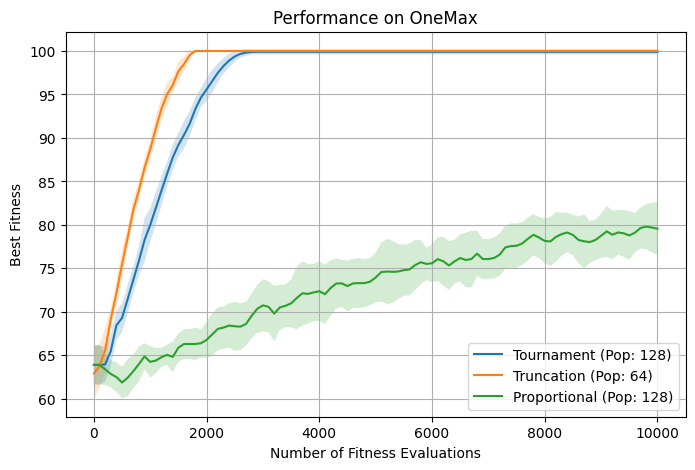

In [50]:
print("OneMax (100 bits)")
results_onemax, best_pops_onemax = run_benchmark(onemax, 100)

print(f"\nKích thước quần thể tốt nhất cho OneMax")
for sel, b_pop in best_pops_onemax.items():
    print(f"  {sel.capitalize()} Selection: {b_pop}")

plot_benchmark("OneMax", results_onemax, best_pops_onemax)

## 7. Thực nghiệm 2: Bài toán LeadingOnes (20 bit)
Tiến hành chạy thực nghiệm, in ra kích thước quần thể tốt nhất và vẽ biểu đồ hiệu năng cho bài toán **LeadingOnes**.

LeadingOnes (20 bits)

Kích thước quần thể tốt nhất cho LeadingOnes
  Tournament Selection: 128
  Truncation Selection: 128
  Proportional Selection: 128


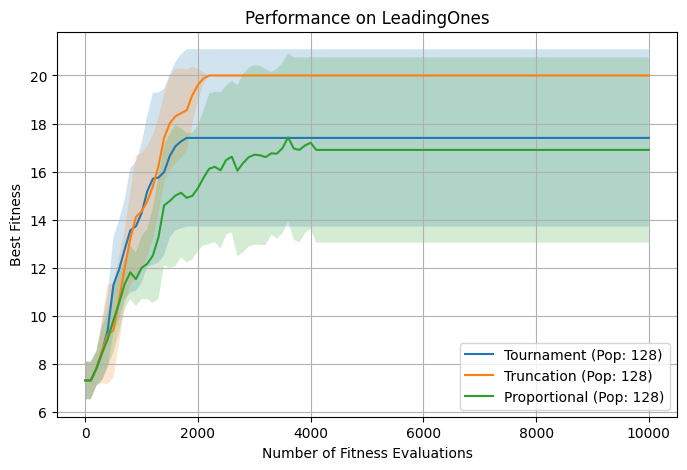

In [51]:
print("LeadingOnes (20 bits)")
results_leadingones, best_pops_leadingones = run_benchmark(leadingones, 20)

print(f"\nKích thước quần thể tốt nhất cho LeadingOnes")
for sel, b_pop in best_pops_leadingones.items():
    print(f"  {sel.capitalize()} Selection: {b_pop}")

plot_benchmark("LeadingOnes", results_leadingones, best_pops_leadingones)

## 8. Thực nghiệm 3: Bài toán Concatenated Trap-5 (25 bit)
Tiến hành chạy thực nghiệm, in ra kích thước quần thể tốt nhất và vẽ biểu đồ hiệu năng cho bài toán **Concatenated Trap-5**.

Concatenated Trap-5 (25 bits)

Kích thước quần thể tốt nhất cho Concatenated Trap-5
  Tournament Selection: 128
  Truncation Selection: 64
  Proportional Selection: 64


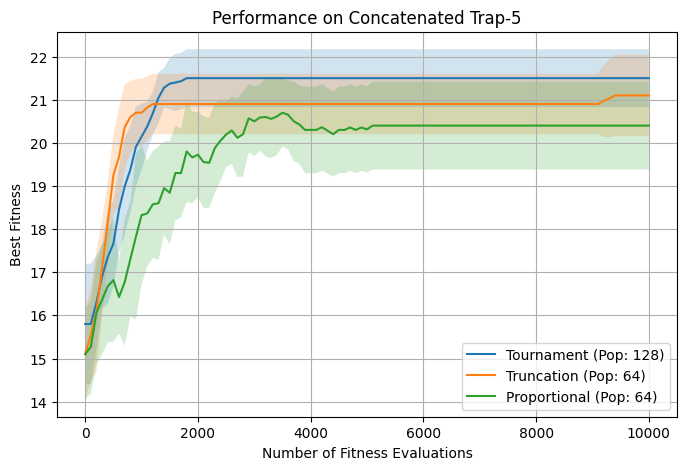

In [52]:
print("Concatenated Trap-5 (25 bits)")
results_trap5, best_pops_trap5 = run_benchmark(trap5, 25)

print(f"\nKích thước quần thể tốt nhất cho Concatenated Trap-5")
for sel, b_pop in best_pops_trap5.items():
    print(f"  {sel.capitalize()} Selection: {b_pop}")

plot_benchmark("Concatenated Trap-5", results_trap5, best_pops_trap5)

## 9. So sánh tổng hợp (Combined Plots)
Gộp 3 đồ thị của 3 bài toán lại với nhau trên cùng một khung hình để có cái nhìn tổng quan, dễ dàng đánh giá sự khác biệt của các cơ chế chọn lọc trên từng địa hình độ thích nghi (fitness landscape) khác nhau.

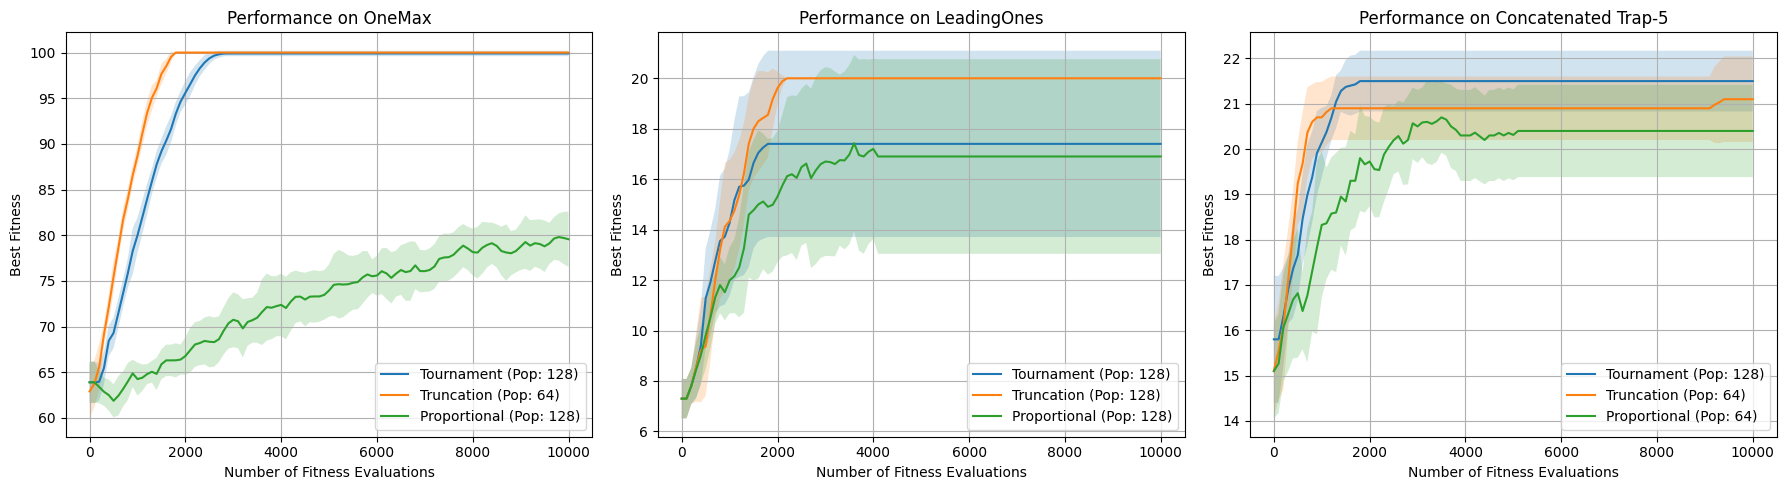

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_benchmark("OneMax", results_onemax, best_pops_onemax, ax=axes[0])
plot_benchmark("LeadingOnes", results_leadingones, best_pops_leadingones, ax=axes[1])
plot_benchmark("Concatenated Trap-5", results_trap5, best_pops_trap5, ax=axes[2])

plt.tight_layout()
plt.show()

# BÁO CÁO KẾT QUẢ THỰC NGHIỆM - THUẬT TOÁN GA (POPOP MODEL)

Dựa trên quá trình chạy thực nghiệm với điều kiện dừng là 10.000 lần đánh giá (fitness evaluations), thử nghiệm các kích thước quần thể $N \in [8, 16, 32, 64, 128]$ qua 10 random seeds khác nhau. Dưới đây là báo cáo về kích thước quần thể (Population Size) cho ra kết quả tốt nhất ở từng cơ chế chọn lọc trên 3 bài toán kiểm thử:

### 1. Hàm OneMax (100 bit)
- **Tournament Selection:** Kích thước quần thể tốt nhất là **128**.
- **Truncation Selection:** Kích thước quần thể tốt nhất là **64**.
- **Proportional Selection:** Kích thước quần thể tốt nhất là **128**.

### 2. Hàm LeadingOnes (20 bit)
- **Tournament Selection:** Kích thước quần thể tốt nhất là **128**.
- **Truncation Selection:** Kích thước quần thể tốt nhất là **128**.
- **Proportional Selection:** Kích thước quần thể tốt nhất là **128**.

### 3. Hàm Concatenated Trap-5 (25 bit)
- **Tournament Selection:** Kích thước quần thể tốt nhất là **128**.
- **Truncation Selection:** Kích thước quần thể tốt nhất là **64**.
- **Proportional Selection:** Kích thước quần thể tốt nhất là **64**.

### Nhận xét chung:

**1. Về kích thước quần thể:**
Do thuật toán **không sử dụng đột biến (no mutation)**, nguồn đa dạng di truyền duy nhất phụ thuộc hoàn toàn vào quần thể khởi tạo. Vì vậy, kích thước quần thể lớn ($N = 64, 128$) là điều kiện bắt buộc để mở rộng không gian tìm kiếm và tránh hiện tượng **hội tụ sớm (premature convergence)**.

**2. Nhận xét về hiệu năng của các phép chọn lọc:**
Sự khác biệt hiệu năng giữa 3 phương pháp nằm ở mức độ **áp lực chọn lọc (selection pressure)**:
* **Truncation Selection:** Áp lực chọn lọc rất cao. Dù hội tụ nhanh ở các bài toán đơn điệu (OneMax, LeadingOnes), nó lại làm mất đa dạng nghiêm trọng và dễ sập bẫy tối ưu cục bộ ở bài toán Trap-5.
* **Proportional Selection:** Kém ổn định nhất. Thuật toán dễ bị đình trệ (stagnation) ở các thế hệ cuối khi chênh lệch fitness giữa các cá thể không còn lớn, gây lãng phí số lần đánh giá.
* **Tournament Selection:** Áp lực chọn lọc cân bằng. Việc chọn lọc không bị phụ thuộc vào giá trị fitness tuyệt đối giúp thuật toán duy trì tốt sự đa dạng di truyền.

**3. Phép chọn lọc nào cho kết quả tốt hơn cả?**
**Tournament Selection** là phương pháp mang lại kết quả xuất sắc và ổn định nhất. Nó cân bằng hoàn hảo giữa khả năng khai thác (giải quyết nhanh OneMax, LeadingOnes) và khả năng khám phá (vượt qua các bẫy cục bộ của Trap-5 mà không bị hội tụ sớm). Do đó, với mô hình POPOP, Tournament là lựa chọn tối ưu nhất.